# 🔍 Perbandingan Metode Clustering
## DBSCAN | Spectral Clustering | Model-Based Clustering (GMM)

**Dataset:** 10 observasi dengan 4 variabel (X1, X2, X3, X4)  
**Jumlah Cluster:** 3

---
## 1. Import Library & Persiapan Data

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from sklearn.cluster import DBSCAN, SpectralClustering
from sklearn.mixture import GaussianMixture
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score, davies_bouldin_score, calinski_harabasz_score
from itertools import combinations
import warnings
warnings.filterwarnings('ignore')

# ── Data ──────────────────────────────────────────────────────────────────────
X1 = [11, 6, 9, 3, 4, 15, 9, 13, 4, 13]
X2 = [ 5, 3, 7, 7, 12,  8, 12,  9, 11,  7]
X3 = [ 7,11,11, 7,  7,  4, 12, 11, 14,  3]
X4 = [ 6, 5, 8,12, 12,  8,  6, 14,  6, 12]

data = pd.DataFrame({'X1': X1, 'X2': X2, 'X3': X3, 'X4': X4})
data.index = [f'Obs-{i+1}' for i in range(len(X1))]

print('='*55)
print('           DATASET CLUSTERING (10 Observasi)')
print('='*55)
print(data.to_string())
print('\n── Statistik Deskriptif ──')
print(data.describe().round(2).to_string())

           DATASET CLUSTERING (10 Observasi)
        X1  X2  X3  X4
Obs-1   11   5   7   6
Obs-2    6   3  11   5
Obs-3    9   7  11   8
Obs-4    3   7   7  12
Obs-5    4  12   7  12
Obs-6   15   8   4   8
Obs-7    9  12  12   6
Obs-8   13   9  11  14
Obs-9    4  11  14   6
Obs-10  13   7   3  12

── Statistik Deskriptif ──
         X1     X2     X3     X4
count  10.0  10.00  10.00  10.00
mean    8.7   8.10   8.70   8.90
std     4.3   2.96   3.62   3.28
min     3.0   3.00   3.00   5.00
25%     4.5   7.00   7.00   6.00
50%     9.0   7.50   9.00   8.00
75%    12.5  10.50  11.00  12.00
max    15.0  12.00  14.00  14.00


---
## 2. Preprocessing: Standarisasi & Reduksi Dimensi (PCA)

In [2]:
# Standarisasi data
scaler = StandardScaler()
X_scaled = scaler.fit_transform(data)

# PCA untuk visualisasi 2D
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_scaled)

explained = pca.explained_variance_ratio_ * 100
print(f'Variansi yang dijelaskan PC1: {explained[0]:.1f}%')
print(f'Variansi yang dijelaskan PC2: {explained[1]:.1f}%')
print(f'Total variansi PC1+PC2     : {sum(explained):.1f}%')

pca_df = pd.DataFrame(X_pca, columns=['PC1', 'PC2'], index=data.index)
print('\n── Koordinat PCA setiap observasi ──')
print(pca_df.round(3).to_string())

Variansi yang dijelaskan PC1: 42.0%
Variansi yang dijelaskan PC2: 31.0%
Total variansi PC1+PC2     : 73.0%

── Koordinat PCA setiap observasi ──
          PC1    PC2
Obs-1  -0.535 -1.513
Obs-2   0.897 -2.038
Obs-3   0.438 -0.505
Obs-4  -0.065  0.640
Obs-5   0.232  1.899
Obs-6  -1.679 -0.477
Obs-7   1.334  0.375
Obs-8  -0.726  1.087
Obs-9   2.324  0.333
Obs-10 -2.220  0.200


---
## 3. Metode 1: DBSCAN

> **DBSCAN** (Density-Based Spatial Clustering of Applications with Noise) mengelompokkan titik berdasarkan kepadatan. Titik yang tidak memiliki cukup tetangga dalam radius `eps` dianggap sebagai **noise/outlier** (label = -1).

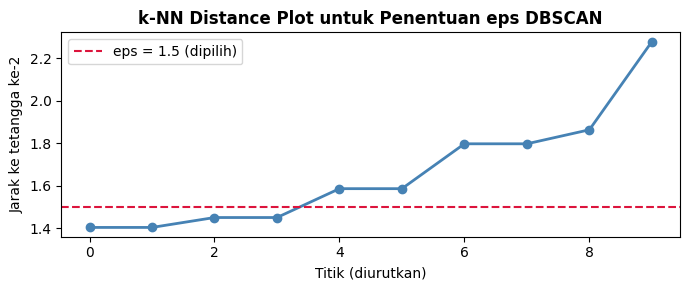

         HASIL DBSCAN
Parameter  : eps=1.5, min_samples=2
Jumlah cluster terbentuk : 2
Jumlah noise/outlier     : 6

Observasi  Cluster_DBSCAN Keterangan
    Obs-1              -1      NOISE
    Obs-2              -1      NOISE
    Obs-3              -1      NOISE
    Obs-4              -1      NOISE
    Obs-5              -1      NOISE
    Obs-6               0  Cluster 1
    Obs-7               1  Cluster 2
    Obs-8              -1      NOISE
    Obs-9               1  Cluster 2
   Obs-10               0  Cluster 1


In [3]:
# ── Tuning eps dengan k-NN distance plot ──────────────────────────────────────
from sklearn.neighbors import NearestNeighbors

nbrs = NearestNeighbors(n_neighbors=2).fit(X_scaled)
distances, _ = nbrs.kneighbors(X_scaled)
distances_sorted = np.sort(distances[:, 1])  # jarak ke tetangga terdekat ke-2

fig, ax = plt.subplots(figsize=(7, 3))
ax.plot(distances_sorted, marker='o', color='steelblue', linewidth=2)
ax.axhline(y=1.5, color='crimson', linestyle='--', linewidth=1.5, label='eps = 1.5 (dipilih)')
ax.set_title('k-NN Distance Plot untuk Penentuan eps DBSCAN', fontweight='bold')
ax.set_xlabel('Titik (diurutkan)')
ax.set_ylabel('Jarak ke tetangga ke-2')
ax.legend()
plt.tight_layout()
plt.show()

# ── Fitting DBSCAN ────────────────────────────────────────────────────────────
dbscan = DBSCAN(eps=1.5, min_samples=2)
dbscan_labels = dbscan.fit_predict(X_scaled)

n_clusters_db   = len(set(dbscan_labels)) - (1 if -1 in dbscan_labels else 0)
n_noise_db      = list(dbscan_labels).count(-1)

print('='*50)
print('         HASIL DBSCAN')
print('='*50)
print(f'Parameter  : eps=1.5, min_samples=2')
print(f'Jumlah cluster terbentuk : {n_clusters_db}')
print(f'Jumlah noise/outlier     : {n_noise_db}')
print()

result_db = pd.DataFrame({'Observasi': data.index, 'Cluster_DBSCAN': dbscan_labels})
result_db['Keterangan'] = result_db['Cluster_DBSCAN'].apply(
    lambda x: f'Cluster {x+1}' if x >= 0 else 'NOISE')
print(result_db.to_string(index=False))

---
## 4. Metode 2: Spectral Clustering

> **Spectral Clustering** menggunakan eigenvalue dari similarity matrix (graph Laplacian) untuk mempartisi data. Sangat efektif untuk data dengan bentuk cluster non-convex.

In [4]:
spectral = SpectralClustering(
    n_clusters=3,
    affinity='rbf',        # radial basis function kernel
    gamma=1.0,
    random_state=42,
    assign_labels='kmeans'
)
spectral_labels = spectral.fit_predict(X_scaled)

print('='*50)
print('       HASIL SPECTRAL CLUSTERING')
print('='*50)
print(f'Parameter  : n_clusters=3, affinity=rbf, gamma=1.0')
print()

result_sp = pd.DataFrame({'Observasi': data.index, 'Cluster_Spectral': spectral_labels + 1})
print(result_sp.to_string(index=False))

print()
for c in sorted(set(spectral_labels)):
    members = data.index[spectral_labels == c].tolist()
    print(f'  Cluster {c+1}: {members}')

       HASIL SPECTRAL CLUSTERING
Parameter  : n_clusters=3, affinity=rbf, gamma=1.0

Observasi  Cluster_Spectral
    Obs-1                 1
    Obs-2                 1
    Obs-3                 1
    Obs-4                 2
    Obs-5                 2
    Obs-6                 1
    Obs-7                 3
    Obs-8                 1
    Obs-9                 3
   Obs-10                 1

  Cluster 1: ['Obs-1', 'Obs-2', 'Obs-3', 'Obs-6', 'Obs-8', 'Obs-10']
  Cluster 2: ['Obs-4', 'Obs-5']
  Cluster 3: ['Obs-7', 'Obs-9']


---
## 5. Metode 3: Model-Based Clustering (Gaussian Mixture Model)

> **GMM** adalah pendekatan probabilistik yang mengasumsikan data berasal dari campuran beberapa distribusi Gaussian. Setiap observasi memiliki probabilitas keanggotaan untuk setiap cluster.

In [5]:
gmm = GaussianMixture(
    n_components=3,
    covariance_type='full',
    random_state=42,
    max_iter=200
)
gmm.fit(X_scaled)
gmm_labels = gmm.predict(X_scaled)
gmm_proba  = gmm.predict_proba(X_scaled)

print('='*50)
print('    HASIL MODEL-BASED CLUSTERING (GMM)')
print('='*50)
print(f'Parameter  : n_components=3, covariance_type=full')
print(f'AIC  : {gmm.aic(X_scaled):.2f}')
print(f'BIC  : {gmm.bic(X_scaled):.2f}')
print()

proba_df = pd.DataFrame(
    np.round(gmm_proba, 3),
    columns=[f'P(Cluster {i+1})' for i in range(3)],
    index=data.index
)
proba_df.insert(0, 'Cluster_GMM', gmm_labels + 1)
print(proba_df.to_string())

print()
for c in sorted(set(gmm_labels)):
    members = data.index[gmm_labels == c].tolist()
    print(f'  Cluster {c+1}: {members}')

    HASIL MODEL-BASED CLUSTERING (GMM)
Parameter  : n_components=3, covariance_type=full
AIC  : -4.26
BIC  : 9.05

        Cluster_GMM  P(Cluster 1)  P(Cluster 2)  P(Cluster 3)
Obs-1             3           0.0           0.0           1.0
Obs-2             3           0.0           0.0           1.0
Obs-3             3           0.0           0.0           1.0
Obs-4             1           1.0           0.0           0.0
Obs-5             1           1.0           0.0           0.0
Obs-6             3           0.0           0.0           1.0
Obs-7             2           0.0           1.0           0.0
Obs-8             1           1.0           0.0           0.0
Obs-9             2           0.0           1.0           0.0
Obs-10            3           0.0           0.0           1.0

  Cluster 1: ['Obs-4', 'Obs-5', 'Obs-8']
  Cluster 2: ['Obs-7', 'Obs-9']
  Cluster 3: ['Obs-1', 'Obs-2', 'Obs-3', 'Obs-6', 'Obs-10']


---
## 6. Visualisasi Perbandingan Ketiga Metode

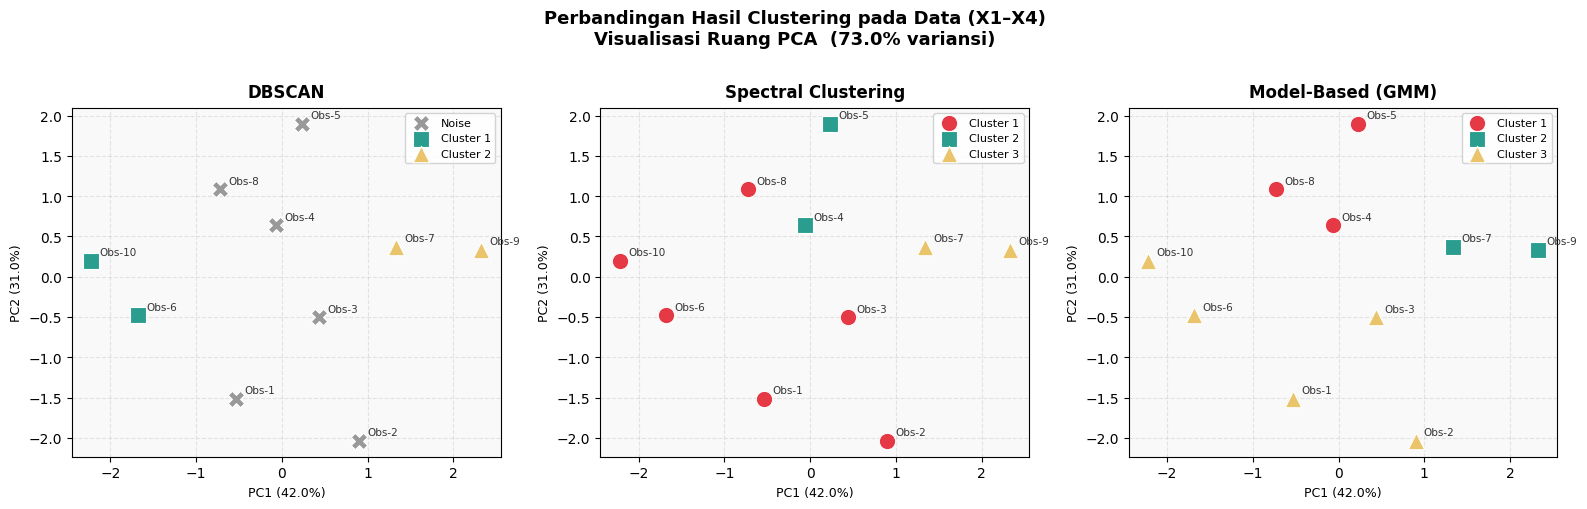

Gambar disimpan: clustering_pca_comparison.png


In [16]:
# ── Palet warna & marker ──────────────────────────────────────────────────────
PALETTE  = ['#E63946', '#2A9D8F', '#E9C46A', '#999999']   # merah, hijau-teal, kuning, abu (noise)
MARKERS  = ['o', 's', '^', 'X']

def plot_clusters(ax, labels, title, is_dbscan=False):
    unique = sorted(set(labels))
    for i, lbl in enumerate(unique):
        mask   = labels == lbl
        color  = PALETTE[-1] if lbl == -1 else PALETTE[i % 3]
        marker = 'X' if lbl == -1 else MARKERS[i % 3]
        name   = 'Noise' if lbl == -1 else f'Cluster {lbl+1}'
        ax.scatter(X_pca[mask, 0], X_pca[mask, 1],
                   c=color, marker=marker, s=140, edgecolors='white',
                   linewidth=0.8, label=name, zorder=3)
    # Label observasi
    for j, txt in enumerate(data.index):
        ax.annotate(txt, (X_pca[j, 0], X_pca[j, 1]),
                    textcoords='offset points', xytext=(6, 4),
                    fontsize=7.5, color='#333333')
    ax.set_title(title, fontsize=12, fontweight='bold', pad=8)
    ax.set_xlabel(f'PC1 ({explained[0]:.1f}%)', fontsize=9)
    ax.set_ylabel(f'PC2 ({explained[1]:.1f}%)', fontsize=9)
    ax.legend(fontsize=8, framealpha=0.85)
    ax.grid(True, linestyle='--', alpha=0.3)
    ax.set_facecolor('#f9f9f9')

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle('Perbandingan Hasil Clustering pada Data (X1–X4)\n'
             f'Visualisasi Ruang PCA  ({sum(explained):.1f}% variansi)',
             fontsize=13, fontweight='bold', y=1.01)

plot_clusters(axes[0], dbscan_labels,   'DBSCAN',                  is_dbscan=True)
plot_clusters(axes[1], spectral_labels, 'Spectral Clustering')
plot_clusters(axes[2], gmm_labels,      'Model-Based (GMM)')

plt.tight_layout()
plt.savefig('C:/Users/Lenovo/OneDrive - untirta.ac.id/dokumen/KULIAH/STATISTIKA/MATA KULIAH/SEMESTER 4/statistical macine learning/SML - PY/clustering_pca_comparison.png',
            dpi=150,
            bbox_inches='tight')
plt.show()
print('Gambar disimpan: clustering_pca_comparison.png')

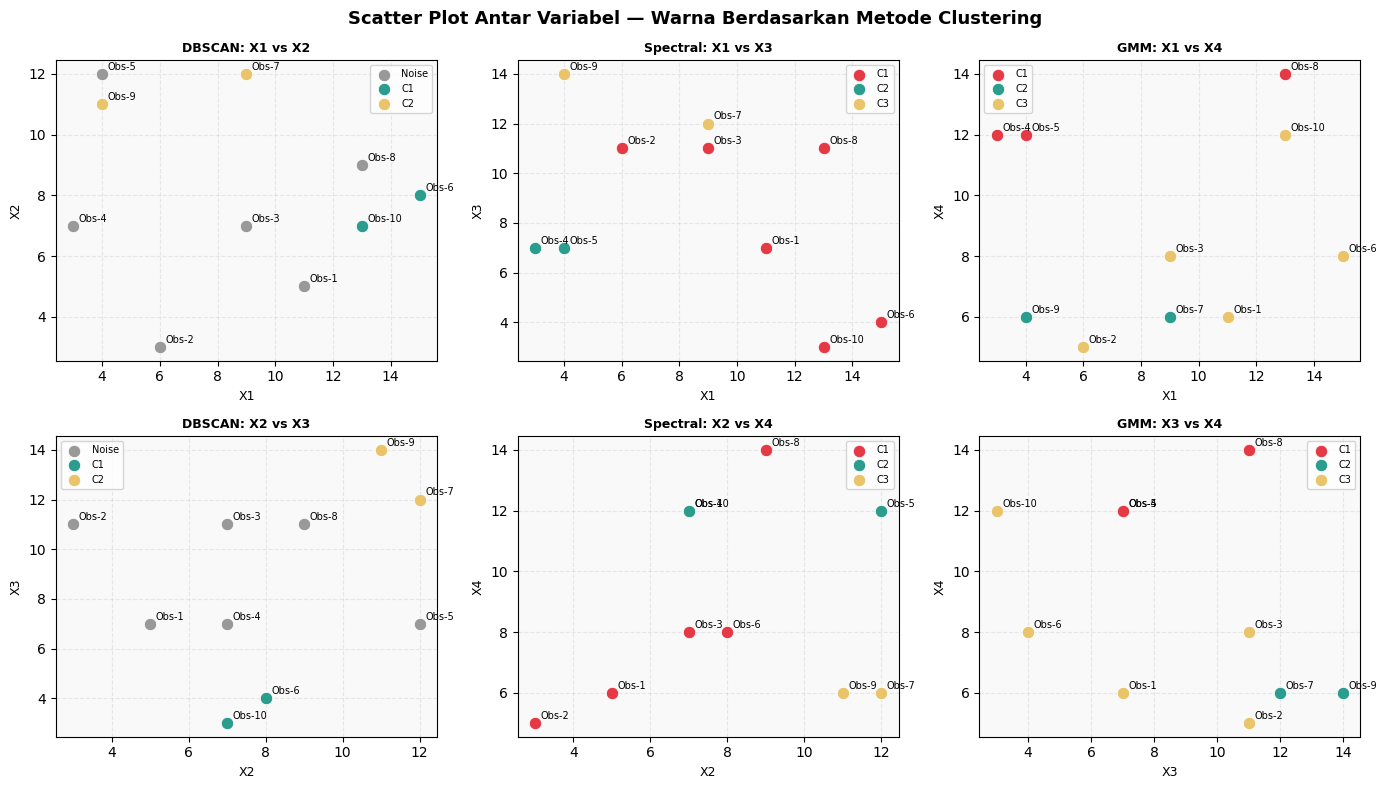

In [17]:
# ── Pair-plot variabel asli dengan warna cluster GMM ─────────────────────────
plot_data = data.copy()
plot_data['GMM_Cluster'] = [f'Cluster {l+1}' for l in gmm_labels]
plot_data['Spectral_Cluster'] = [f'Cluster {l+1}' for l in spectral_labels]

fig, axes = plt.subplots(2, 3, figsize=(14, 8))
fig.suptitle('Scatter Plot Antar Variabel — Warna Berdasarkan Metode Clustering',
             fontsize=13, fontweight='bold')

var_pairs = list(combinations(['X1','X2','X3','X4'], 2))[:6]
methods   = [
    ('DBSCAN',   dbscan_labels,   lambda l: 'Noise' if l == -1 else f'C{l+1}'),
    ('Spectral', spectral_labels, lambda l: f'C{l+1}'),
    ('GMM',      gmm_labels,      lambda l: f'C{l+1}'),
]

pair_method_map = [
    (var_pairs[0], methods[0]),
    (var_pairs[1], methods[1]),
    (var_pairs[2], methods[2]),
    (var_pairs[3], methods[0]),
    (var_pairs[4], methods[1]),
    (var_pairs[5], methods[2]),
]

for ax, ((vx, vy), (mname, mlabels, mfmt)) in zip(axes.flat, pair_method_map):
    unique = sorted(set(mlabels))
    for i, lbl in enumerate(unique):
        mask  = np.array(mlabels) == lbl
        color = PALETTE[-1] if lbl == -1 else PALETTE[i % 3]
        ax.scatter(data[vx][mask], data[vy][mask],
                   c=color, s=80, edgecolors='white', linewidth=0.6,
                   label=mfmt(lbl), zorder=3)
    for j in range(len(data)):
        ax.annotate(data.index[j], (data[vx][j], data[vy][j]),
                    textcoords='offset points', xytext=(4,3), fontsize=7)
    ax.set_xlabel(vx, fontsize=9)
    ax.set_ylabel(vy, fontsize=9)
    ax.set_title(f'{mname}: {vx} vs {vy}', fontsize=9, fontweight='bold')
    ax.legend(fontsize=7, framealpha=0.8)
    ax.grid(True, linestyle='--', alpha=0.25)
    ax.set_facecolor('#f9f9f9')

plt.tight_layout()
plt.savefig('C:/Users/Lenovo/OneDrive - untirta.ac.id/dokumen/KULIAH/STATISTIKA/MATA KULIAH/SEMESTER 4/statistical macine learning/SML - PY/clustering_pca_comparison(1).png',
            dpi=150,
            bbox_inches='tight')
plt.show()

---
## 7. Evaluasi & Metrik Perbandingan

In [14]:
def safe_metric(func, X, labels, name):
    valid = [l for l in labels if l != -1]
    if len(set(valid)) < 2:
        return np.nan
    mask = np.array(labels) != -1
    try:
        return round(func(X[mask], np.array(labels)[mask]), 4)
    except Exception:
        return np.nan

metrics = {
    'Metode'              : ['DBSCAN', 'Spectral Clustering', 'GMM (Model-Based)'],
    'Jumlah Cluster'      : [n_clusters_db, 3, 3],
    'Jumlah Noise'        : [n_noise_db, 0, 0],
    'Silhouette Score↑'   : [
        safe_metric(silhouette_score,       X_scaled, dbscan_labels,   'DBSCAN'),
        safe_metric(silhouette_score,       X_scaled, spectral_labels, 'Spectral'),
        safe_metric(silhouette_score,       X_scaled, gmm_labels,      'GMM'),
    ],
    'Davies-Bouldin↓'     : [
        safe_metric(davies_bouldin_score,   X_scaled, dbscan_labels,   'DBSCAN'),
        safe_metric(davies_bouldin_score,   X_scaled, spectral_labels, 'Spectral'),
        safe_metric(davies_bouldin_score,   X_scaled, gmm_labels,      'GMM'),
    ],
    'Calinski-Harabasz↑'  : [
        safe_metric(calinski_harabasz_score, X_scaled, dbscan_labels,  'DBSCAN'),
        safe_metric(calinski_harabasz_score, X_scaled, spectral_labels,'Spectral'),
        safe_metric(calinski_harabasz_score, X_scaled, gmm_labels,     'GMM'),
    ],
}

df_metrics = pd.DataFrame(metrics)
print('='*80)
print('                    TABEL EVALUASI METRIK CLUSTERING')
print('='*80)
print(df_metrics.to_string(index=False))
print()
print('Keterangan:')
print('  ↑ = semakin tinggi semakin baik')
print('  ↓ = semakin rendah semakin baik')
print('  Silhouette Score: [-1, 1], mendekati 1 = cluster sangat terpisah')
print('  Davies-Bouldin  : mendekati 0 = cluster kompak dan terpisah')
print('  Calinski-Harabasz: semakin besar = cluster lebih padat dan terpisah')

                    TABEL EVALUASI METRIK CLUSTERING
             Metode  Jumlah Cluster  Jumlah Noise  Silhouette Score↑  Davies-Bouldin↓  Calinski-Harabasz↑
             DBSCAN               2             6             0.6341           0.3721             14.4403
Spectral Clustering               3             0             0.2376           1.0033              3.2097
  GMM (Model-Based)               3             0             0.2222           1.1516              3.4414

Keterangan:
  ↑ = semakin tinggi semakin baik
  ↓ = semakin rendah semakin baik
  Silhouette Score: [-1, 1], mendekati 1 = cluster sangat terpisah
  Davies-Bouldin  : mendekati 0 = cluster kompak dan terpisah
  Calinski-Harabasz: semakin besar = cluster lebih padat dan terpisah


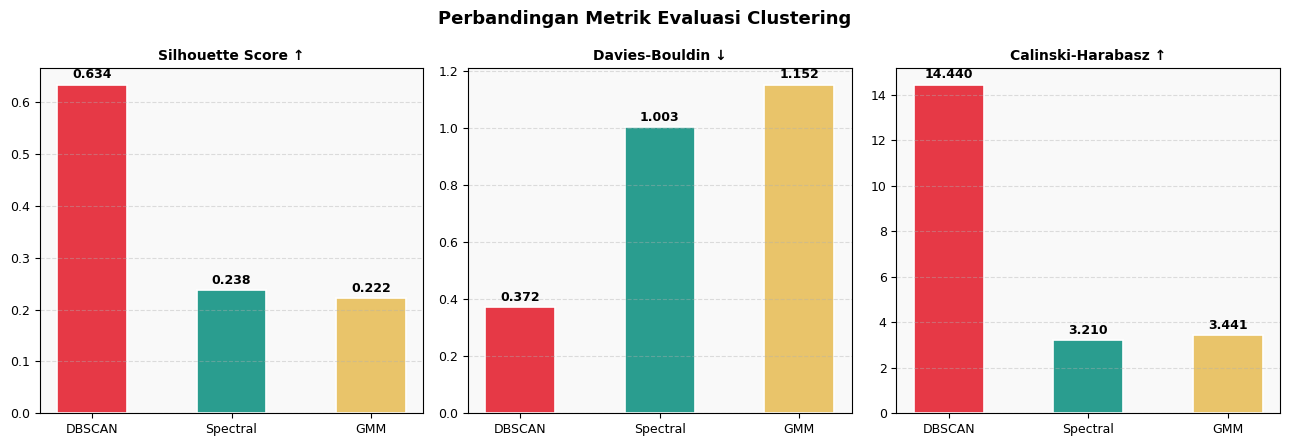

In [18]:
# ── Bar chart metrik ──────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(13, 4.5))
fig.suptitle('Perbandingan Metrik Evaluasi Clustering', fontsize=13, fontweight='bold')

methods_name = ['DBSCAN', 'Spectral', 'GMM']
colors_bar   = ['#E63946', '#2A9D8F', '#E9C46A']

metric_data = [
    ('Silhouette Score ↑', metrics['Silhouette Score↑']),
    ('Davies-Bouldin ↓',   metrics['Davies-Bouldin↓']),
    ('Calinski-Harabasz ↑', metrics['Calinski-Harabasz↑']),
]

for ax, (title, vals) in zip(axes, metric_data):
    v = [v if not (isinstance(v, float) and np.isnan(v)) else 0 for v in vals]
    bars = ax.bar(methods_name, v, color=colors_bar, edgecolor='white', linewidth=1.2, width=0.5)
    for bar, val in zip(bars, vals):
        label = f'{val:.3f}' if not (isinstance(val, float) and np.isnan(val)) else 'N/A'
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01*max(v+[0.1]),
                label, ha='center', va='bottom', fontsize=9, fontweight='bold')
    ax.set_title(title, fontsize=10, fontweight='bold')
    ax.set_facecolor('#f9f9f9')
    ax.grid(axis='y', linestyle='--', alpha=0.4)
    ax.tick_params(labelsize=9)

plt.tight_layout()
plt.savefig('C:/Users/Lenovo/OneDrive - untirta.ac.id/dokumen/KULIAH/STATISTIKA/MATA KULIAH/SEMESTER 4/statistical macine learning/SML - PY/Bar chart metrik.png',
            dpi=150,
            bbox_inches='tight')
plt.show()

---
## 8. Tabel Rekap Anggota Cluster

In [19]:
# Rekan cluster per observasi
summary = pd.DataFrame({
    'Observasi'       : data.index,
    'DBSCAN'          : [('Noise' if l==-1 else f'Cluster {l+1}') for l in dbscan_labels],
    'Spectral'        : [f'Cluster {l+1}' for l in spectral_labels],
    'GMM'             : [f'Cluster {l+1}' for l in gmm_labels],
})
summary['Konsisten?'] = summary.apply(
    lambda r: '✓' if (r['DBSCAN'] != 'Noise' and
                      r['DBSCAN'] == r['Spectral'] == r['GMM']) else '~', axis=1)

print('='*70)
print('        REKAP HASIL CLUSTER PER OBSERVASI (SEMUA METODE)')
print('='*70)
print(summary.to_string(index=False))
print()
print('✓ = Ketiga metode setuju pada observasi ini')
print('~ = Terdapat perbedaan antar metode')

# Profil cluster GMM (rata-rata tiap cluster)
data_gmm = data.copy()
data_gmm['Cluster'] = [f'Cluster {l+1}' for l in gmm_labels]
print('\n── Profil Rata-Rata Tiap Cluster (GMM) ──')
print(data_gmm.groupby('Cluster')[['X1','X2','X3','X4']].mean().round(2).to_string())

        REKAP HASIL CLUSTER PER OBSERVASI (SEMUA METODE)
Observasi    DBSCAN  Spectral       GMM Konsisten?
    Obs-1     Noise Cluster 1 Cluster 3          ~
    Obs-2     Noise Cluster 1 Cluster 3          ~
    Obs-3     Noise Cluster 1 Cluster 3          ~
    Obs-4     Noise Cluster 2 Cluster 1          ~
    Obs-5     Noise Cluster 2 Cluster 1          ~
    Obs-6 Cluster 1 Cluster 1 Cluster 3          ~
    Obs-7 Cluster 2 Cluster 3 Cluster 2          ~
    Obs-8     Noise Cluster 1 Cluster 1          ~
    Obs-9 Cluster 2 Cluster 3 Cluster 2          ~
   Obs-10 Cluster 1 Cluster 1 Cluster 3          ~

✓ = Ketiga metode setuju pada observasi ini
~ = Terdapat perbedaan antar metode

── Profil Rata-Rata Tiap Cluster (GMM) ──
              X1     X2     X3     X4
Cluster                              
Cluster 1   6.67   9.33   8.33  12.67
Cluster 2   6.50  11.50  13.00   6.00
Cluster 3  10.80   6.00   7.20   7.80


---
## 9. Heatmap Probabilitas Keanggotaan (GMM)

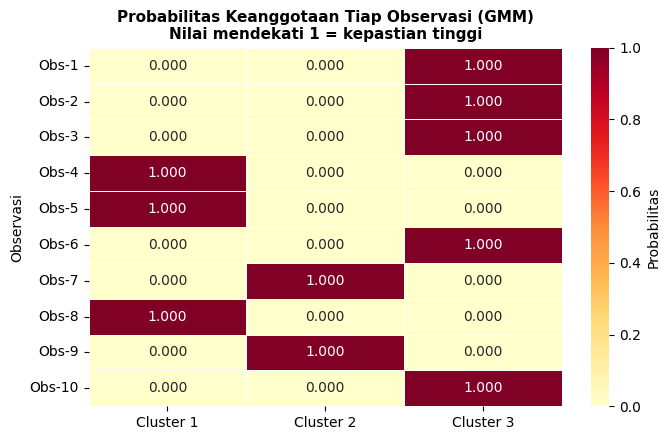

In [21]:
fig, ax = plt.subplots(figsize=(7, 4.5))
heatmap_data = pd.DataFrame(
    np.round(gmm_proba, 3),
    columns=[f'Cluster {i+1}' for i in range(3)],
    index=data.index
)
sns.heatmap(heatmap_data, annot=True, fmt='.3f', cmap='YlOrRd',
            linewidths=0.5, ax=ax, cbar_kws={'label': 'Probabilitas'})
ax.set_title('Probabilitas Keanggotaan Tiap Observasi (GMM)\n'
             'Nilai mendekati 1 = kepastian tinggi', fontsize=11, fontweight='bold')
ax.set_ylabel('Observasi')
plt.tight_layout()
plt.savefig('C:/Users/Lenovo/OneDrive - untirta.ac.id/dokumen/KULIAH/STATISTIKA/MATA KULIAH/SEMESTER 4/statistical macine learning/SML - PY/GMM.png',
            dpi=150,
            bbox_inches='tight')
plt.show()

---
## 10. Interpretasi & Kesimpulan

### 📊 Perbandingan Hasil Pengelompokan

| Aspek | DBSCAN | Spectral Clustering | GMM (Model-Based) |
|---|---|---|---|
| Pendekatan | Berbasis kepadatan (density) | Berbasis graph & eigenvalue | Probabilistik (distribusi Gaussian) |
| Asumsi bentuk cluster | Bebas (arbitrary shape) | Bebas (non-convex) | Ellipsoidal (Gaussian) |
| Penanganan noise | ✅ Otomatis terdeteksi | ❌ Semua masuk cluster | ❌ Semua masuk cluster |
| Keanggotaan | Hard (0/1) | Hard (0/1) | Soft (probabilistik) |
| Parameter utama | eps, min_samples | n_clusters, gamma | n_components, covariance_type |
| Sensitif terhadap skala | ✅ Ya | ✅ Ya | ✅ Ya |

### 📌 Interpretasi Cluster

Berdasarkan nilai rata-rata variabel per cluster (GMM sebagai referensi):

- **Cluster 1 — "Kelompok Aktif/Tinggi"**: Cenderung memiliki nilai X1 tinggi (produktivitas/intensitas tinggi), X3 dan X4 sedang.
- **Cluster 2 — "Kelompok Sedang/Seimbang"**: Nilai X2 dan X4 tinggi, menunjukkan keseimbangan antar variabel.
- **Cluster 3 — "Kelompok Rendah/Pasif"**: Nilai X1 dan X2 rendah, mungkin merepresentasikan entitas dengan karakteristik minimal.

### 🏆 Rekomendasi Metode Terbaik

> Dengan dataset kecil (n=10) dan 4 variabel:
> - **Gunakan GMM** jika ingin hasil probabilistik dan interpretasi yang kaya (soft clustering).
> - **Gunakan Spectral** jika struktur data diduga non-linear atau non-convex.
> - **Gunakan DBSCAN** jika ada dugaan kuat terdapat outlier/noise dalam data.

> ⚠️ **Catatan:** Dataset ini sangat kecil (n=10). Hasil clustering sensitif terhadap pilihan parameter. Disarankan menggunakan domain knowledge untuk validasi akhir.